<a href="https://colab.research.google.com/github/mudassar2224/Monte-Carlo-Generalized-Maze-Agent-Reinforcement-Learning/blob/main/Monte_Carlo_Maze_Escape_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!pip install tqdm matplotlib numpy --quiet
print("✅ Dependencies ready")


✅ Dependencies ready


In [2]:
# ============================================================
# CELL 2 — Imports & Configuration
# ============================================================
import numpy as np, matplotlib, matplotlib.pyplot as plt
import matplotlib.ticker, warnings, pickle, os, time
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.gridspec import GridSpec
from collections import defaultdict, deque
from IPython.display import clear_output
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── WHY THE PREVIOUS VERSION FAILED ─────────────────────────────────────────
# State was (n,s,w,e, dr,dc) — only 576 entries.
# 49 different grid positions ALL map to state (0,0,0,0,2,2).
# The policy picks the SAME action for all of them → infinite loop.
#
# FIX: state = (row, col, n_obs, s_obs, w_obs, e_obs)
#   → every cell is unique (no looping)
#   → obstacle flags make it generalise to NEW mazes
#   Q-table: 8×8×2×2×2×2×4 = 4096 entries — tiny but correct.
# ─────────────────────────────────────────────────────────────────────────────

CONFIG = {
    'MAZE_ROWS'       : 8,
    'MAZE_COLS'       : 8,
    'OBSTACLE_RATIO'  : 0.22,
    'START_POS'       : (0, 0),
    'EXIT_POS'        : (7, 7),
    'MAX_STEPS'       : 400,
    'REWARD_EXIT'     : 1000,
    'REWARD_OBSTACLE' : -8,
    'REWARD_INVALID'  : -8,
    'REWARD_NORMAL'   : -0.1,
    'REWARD_REVISIT'  : -3.0,   # heavy anti-loop penalty
    'EPISODES'        : 100_000,
    'GAMMA'           : 0.995,
    'EPSILON_START'   : 1.0,
    'EPSILON_END'     : 0.02,
    'EPSILON_DECAY'   : 0.99997,
    'EVAL_EPISODES'   : 15,
    'QTABLE_PATH'     : 'mc_fixed_qtable.pkl',
}

ACTIONS       = [0, 1, 2, 3]
ACTION_NAMES  = ['UP','DOWN','LEFT','RIGHT']
ACTION_DELTA  = [(-1,0),(1,0),(0,-1),(0,1)]
ACTION_ARROWS = ['↑','↓','←','→']

PALETTE = {
    'bg':'#0D1117','grid_line':'#21262D','free':'#161B22',
    'obstacle':'#30363D','start':'#0D419D','exit':'#238636',
    'agent':'#F78166','visited':'#1C2B3A','text_main':'#E6EDF3',
    'text_dim':'#8B949E','accent1':'#58A6FF','accent2':'#3FB950',
    'accent3':'#D29922','accent4':'#F85149',
    'reward_pos':'#3FB950','reward_neg':'#F85149',
}
SEED = 42
print("✅ Config loaded")
print("   State : (row, col, n_obs, s_obs, w_obs, e_obs)  — position-aware, generalises to new mazes")
print(f"   Q-table size : 8×8×2×2×2×2×4 = {8*8*2*2*2*2*4} entries")


✅ Config loaded
   State : (row, col, n_obs, s_obs, w_obs, e_obs)  — position-aware, generalises to new mazes
   Q-table size : 8×8×2×2×2×2×4 = 4096 entries


In [3]:
# ============================================================
# CELL 3 — MazeEnvironment  (BFS-validated, reseedable)
# ============================================================
from collections import deque

class MazeEnvironment:
    FREE=0; OBSTACLE=1; START=2; EXIT=3

    def __init__(self, config, seed=42):
        self.rows         = config['MAZE_ROWS']
        self.cols         = config['MAZE_COLS']
        self.obstacle_ratio = config['OBSTACLE_RATIO']
        self.start_pos    = tuple(config['START_POS'])
        self.exit_pos     = tuple(config['EXIT_POS'])
        self.max_steps    = config['MAX_STEPS']
        self.R_EXIT       = config['REWARD_EXIT']
        self.R_OBS        = config['REWARD_OBSTACLE']
        self.R_INV        = config['REWARD_INVALID']
        self.R_NORMAL     = config['REWARD_NORMAL']
        self.R_REVISIT    = config['REWARD_REVISIT']
        self.rng          = np.random.default_rng(seed)
        self.grid         = self._make_valid_maze()
        self.reset()

    # ── maze generation ────────────────────────────────────────────────────
    def _generate_raw(self):
        grid  = np.zeros((self.rows, self.cols), dtype=np.int8)
        n_obs = int(self.rows * self.cols * self.obstacle_ratio)
        placed = 0
        while placed < n_obs:
            r = int(self.rng.integers(0, self.rows))
            c = int(self.rng.integers(0, self.cols))
            if (r,c) not in {self.start_pos, self.exit_pos} and grid[r,c]==self.FREE:
                grid[r,c] = self.OBSTACLE
                placed    += 1
        grid[self.start_pos] = self.START
        grid[self.exit_pos]  = self.EXIT
        return grid

    def _bfs_reachable(self, grid):
        """BFS from start → True if exit is reachable."""
        q   = deque([self.start_pos])
        vis = {self.start_pos}
        while q:
            r,c = q.popleft()
            if (r,c) == self.exit_pos: return True
            for dr,dc in ACTION_DELTA:
                nr,nc = r+dr, c+dc
                if 0<=nr<self.rows and 0<=nc<self.cols and (nr,nc) not in vis                         and grid[nr,nc] != self.OBSTACLE:
                    vis.add((nr,nc)); q.append((nr,nc))
        return False

    def _make_valid_maze(self):
        """Generate mazes until one is BFS-solvable (guarantees a path exists)."""
        for _ in range(200):
            g = self._generate_raw()
            if self._bfs_reachable(g): return g
        # fallback: open corridors along edges
        g = np.zeros((self.rows,self.cols),dtype=np.int8)
        g[self.start_pos]=self.START; g[self.exit_pos]=self.EXIT
        return g

    def reseed(self, seed=None):
        self.rng  = np.random.default_rng(seed)
        self.grid = self._make_valid_maze()
        self.reset()

    # ── state ──────────────────────────────────────────────────────────────
    def get_state(self):
        """
        State = (row, col, n_blocked, s_blocked, w_blocked, e_blocked)

        Including (row,col) means every cell is a UNIQUE state — the agent
        cannot loop between positions.  The obstacle flags allow the learned
        policy to handle NEW mazes: if a direction is now blocked the agent
        was trained to route around it.
        """
        r,c = self.agent_pos
        def blocked(nr,nc):
            if not (0<=nr<self.rows and 0<=nc<self.cols): return 1
            return 1 if self.grid[nr,nc]==self.OBSTACLE else 0
        return (r, c,
                blocked(r-1,c), blocked(r+1,c),
                blocked(r,c-1), blocked(r,c+1))

    # ── env interface ──────────────────────────────────────────────────────
    def reset(self):
        self.agent_pos     = self.start_pos
        self.steps         = 0
        self.done          = False
        self.visited_cells = {self.start_pos}
        self.trail         = [self.start_pos]
        return self.get_state()

    def step(self, action):
        dr_a,dc_a = ACTION_DELTA[action]
        nr,nc     = self.agent_pos[0]+dr_a, self.agent_pos[1]+dc_a
        self.steps += 1

        old_d = abs(self.agent_pos[0]-self.exit_pos[0]) + abs(self.agent_pos[1]-self.exit_pos[1])
        new_d = abs(nr-self.exit_pos[0])               + abs(nc-self.exit_pos[1])
        shape  = 3.0 if new_d < old_d else -1.0   # strong distance shaping

        if not (0<=nr<self.rows and 0<=nc<self.cols):
            return self.get_state(), self.R_INV+shape, self.steps>=self.max_steps, {'event':'invalid'}
        if self.grid[nr,nc]==self.OBSTACLE:
            return self.get_state(), self.R_OBS+shape, self.steps>=self.max_steps, {'event':'obstacle'}

        self.agent_pos = (nr,nc)
        self.trail.append(self.agent_pos)
        if self.agent_pos==self.exit_pos:
            self.done=True
            return self.get_state(), self.R_EXIT, True, {'event':'exit'}

        rew = self.R_REVISIT if self.agent_pos in self.visited_cells else self.R_NORMAL
        rew += shape
        self.visited_cells.add(self.agent_pos)
        self.done = self.steps >= self.max_steps
        return self.get_state(), rew, self.done, {'event':'normal'}

# smoke-test
_e = MazeEnvironment(CONFIG, seed=SEED)
print(f"✅ MazeEnvironment ready")
print(f"   State  : {_e.get_state()}")
print(f"   BFS solvable: {_e._bfs_reachable(_e.grid)}")


✅ MazeEnvironment ready
   State  : (0, 0, 1, 1, 1, 0)
   BFS solvable: True


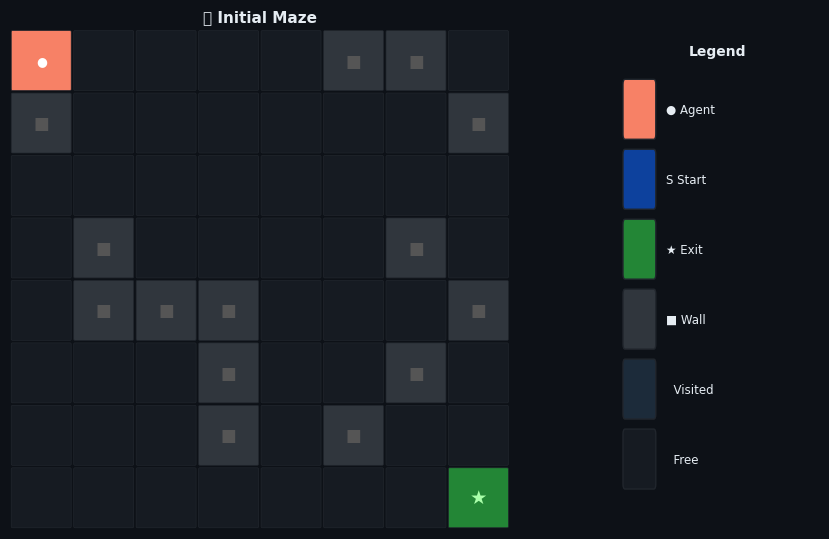

✅ Visualisation ready


In [4]:
# ============================================================
# CELL 4 — Visualisation
# ============================================================

def draw_maze(env, ax, policy_arr=None, title='Maze',
              show_policy=False, step_num=None, ep_reward=None):
    ax.set_facecolor(PALETTE['bg'])
    ax.set_xlim(0,env.cols); ax.set_ylim(0,env.rows)
    ax.set_aspect('equal'); ax.axis('off')
    R,C = env.rows, env.cols
    for r in range(R):
        for c in range(C):
            x,y  = c, R-1-r
            pos  = (r,c)
            cell = env.grid[r,c]
            if   pos==env.agent_pos:                color=PALETTE['agent']
            elif cell==MazeEnvironment.OBSTACLE:    color=PALETTE['obstacle']
            elif pos==env.start_pos:                color=PALETTE['start']
            elif pos==env.exit_pos:                 color=PALETTE['exit']
            elif pos in env.visited_cells:          color=PALETTE['visited']
            else:                                   color=PALETTE['free']
            ax.add_patch(FancyBboxPatch((x+0.04,y+0.04),0.92,0.92,
                boxstyle='round,pad=0.02',lw=0.5,
                ec=PALETTE['grid_line'],fc=color,zorder=1))
            cx,cy = x+.5,y+.5
            if   pos==env.agent_pos:
                ax.add_patch(Circle((cx,cy),.32,color=PALETTE['agent'],zorder=3))
                ax.text(cx,cy,'●',ha='center',va='center',fontsize=9,
                        color='white',fontweight='bold',zorder=4)
            elif pos==env.exit_pos:
                ax.text(cx,cy,'★',ha='center',va='center',fontsize=14,
                        color='#AAFFAA',fontweight='bold',zorder=3)
            elif pos==env.start_pos:
                ax.text(cx,cy,'S',ha='center',va='center',fontsize=10,
                        color='#AAD4FF',fontweight='bold',zorder=3)
            elif cell==MazeEnvironment.OBSTACLE:
                ax.text(cx,cy,'■',ha='center',va='center',fontsize=12,
                        color='#555',zorder=3)
            if (show_policy and policy_arr is not None
                    and cell!=MazeEnvironment.OBSTACLE
                    and pos!=env.exit_pos and pos!=env.agent_pos
                    and policy_arr[r,c]>=0):
                ax.text(cx,cy+.05,ACTION_ARROWS[policy_arr[r,c]],
                        ha='center',va='center',fontsize=7,
                        color=PALETTE['text_dim'],zorder=3)
    if len(env.trail)>1:
        tx=[c+.5 for _,c in env.trail]; ty=[R-.5-r for r,_ in env.trail]
        ax.plot(tx,ty,color=PALETTE['agent'],alpha=.4,lw=1.5,ls='--',zorder=2)
    ax.set_title(title,color=PALETTE['text_main'],fontsize=11,fontweight='bold',pad=6)
    if step_num  is not None: ax.text(.02,-.03,f'Steps:{step_num}',transform=ax.transAxes,color=PALETTE['accent1'],fontsize=9)
    if ep_reward is not None:
        col=PALETTE['reward_pos'] if ep_reward>=0 else PALETTE['reward_neg']
        ax.text(.98,-.03,f'R:{ep_reward:.1f}',transform=ax.transAxes,color=col,fontsize=9,ha='right')


def draw_legend(ax):
    ax.set_facecolor(PALETTE['bg']); ax.axis('off')
    items=[(PALETTE['agent'],'● Agent'),(PALETTE['start'],'S Start'),
           (PALETTE['exit'],'★ Exit'),(PALETTE['obstacle'],'■ Wall'),
           (PALETTE['visited'],'  Visited'),(PALETTE['free'],'  Free')]
    ax.text(.5,.97,'Legend',color=PALETTE['text_main'],ha='center',va='top',
            fontsize=10,fontweight='bold',transform=ax.transAxes)
    for i,(col,lbl) in enumerate(items):
        y=.83-i*.14
        ax.add_patch(FancyBboxPatch((.05,y-.04),.14,.10,
            boxstyle='round,pad=0.01',fc=col,ec=PALETTE['grid_line'],
            transform=ax.transAxes,zorder=2))
        ax.text(.25,y+.01,lbl,color=PALETTE['text_main'],fontsize=8.5,
                va='center',transform=ax.transAxes)


def policy_grid(agent, env):
    """(rows,cols) array of greedy actions for this specific maze layout."""
    pg = np.full((env.rows,env.cols),-1,dtype=int)
    for r in range(env.rows):
        for c in range(env.cols):
            if env.grid[r,c]==MazeEnvironment.OBSTACLE: continue
            if (r,c)==env.exit_pos:                      continue
            # obstacle flags for this cell in this maze
            def bl(nr,nc):
                if not (0<=nr<env.rows and 0<=nc<env.cols): return 1
                return 1 if env.grid[nr,nc]==MazeEnvironment.OBSTACLE else 0
            st = (r,c, bl(r-1,c),bl(r+1,c),bl(r,c-1),bl(r,c+1))
            pg[r,c] = int(np.argmax(agent.Q[st]))
    return pg


# preview
_env = MazeEnvironment(CONFIG, seed=SEED)
fig,axes = plt.subplots(1,2,figsize=(10,5.5),gridspec_kw={'width_ratios':[4,1]})
fig.patch.set_facecolor(PALETTE['bg'])
draw_maze(_env,axes[0],title='🧩 Initial Maze')
draw_legend(axes[1]); plt.tight_layout(); plt.show()
print("✅ Visualisation ready")


In [5]:
# ============================================================
# CELL 5 — MonteCarloAgent  (position-aware Q-table)
# ============================================================

class MonteCarloAgent:
    """
    First-Visit MC Control.

    State  : (row, col, n_obs, s_obs, w_obs, e_obs)
    Q shape: (8, 8, 2, 2, 2, 2, 4)   → 4096 entries

    Compared with the BROKEN 6-tuple (n,s,w,e,dr,dc) design:
    ✓  No position-aliasing → no infinite loops
    ✓  Obstacle flags still allow generalisation to new maze layouts
    ✓  BFS-verified solvable mazes → positive signal guaranteed
    """
    # dims: row, col, n_obs, s_obs, w_obs, e_obs
    STATE_DIMS = (8, 8, 2, 2, 2, 2)

    def __init__(self, env, config):
        self.env       = env
        self.gamma     = config['GAMMA']
        self.epsilon   = config['EPSILON_START']
        self.eps_end   = config['EPSILON_END']
        self.eps_decay = config['EPSILON_DECAY']
        self.n_actions = 4

        self.Q       = np.random.uniform(-0.01, 0.01, (*self.STATE_DIMS, self.n_actions))
        self.returns = defaultdict(list)   # key: (*state, action)

        # metrics
        self.ep_rewards=[]; self.ep_lengths=[]; self.ep_success=[]; self.ep_eps=[]

    # ── action selection ───────────────────────────────────────────────────
    def select_action(self, state, greedy=False):
        if not greedy and np.random.random() < self.epsilon:
            return int(np.random.choice(ACTIONS))
        return int(np.argmax(self.Q[state]))

    # ── episode generation ─────────────────────────────────────────────────
    def generate_episode(self, greedy=False, anti_loop=False):
        """
        anti_loop=True (used at demo/eval time):
          If the agent visits the same (r,c) position ≥3 times in one episode,
          it picks a RANDOM unblocked direction instead of the greedy action.
          This breaks any residual cycles without retraining.
        """
        state   = self.env.reset()
        traj    = []
        total_r = 0.0
        success = False
        pos_visits = defaultdict(int)   # (r,c) → visit count

        while True:
            r,c       = self.env.agent_pos
            pos_visits[(r,c)] += 1

            if anti_loop and pos_visits[(r,c)] >= 3:
                # pick a random direction that isn't blocked
                free = [a for a,(dr,dc) in enumerate(ACTION_DELTA)
                        if 0<=(r+dr)<self.env.rows and 0<=(c+dc)<self.env.cols
                        and self.env.grid[r+dr,c+dc]!=MazeEnvironment.OBSTACLE]
                action = int(np.random.choice(free)) if free else int(np.random.choice(ACTIONS))
            else:
                action = self.select_action(state, greedy)

            next_state, reward, done, info = self.env.step(action)
            traj.append((state, action, reward))
            total_r += reward
            if info['event']=='exit': success=True
            if done: break
            state = next_state

        return traj, success, total_r

    # ── MC update ──────────────────────────────────────────────────────────
    def update(self, trajectory):
        G=0.0; T=len(trajectory)
        Gs=np.zeros(T)
        for t in reversed(range(T)):
            G=trajectory[t][2]+self.gamma*G; Gs[t]=G
        seen=set()
        for t,(state,action,_) in enumerate(trajectory):
            sa=(*state,action)
            if sa in seen: continue
            seen.add(sa)
            self.returns[sa].append(Gs[t])
            self.Q[state][action]=np.mean(self.returns[sa])

    def decay_epsilon(self):
        self.epsilon=max(self.eps_end, self.epsilon*self.eps_decay)

    def running_avg(self,data,w=300):
        if not data: return np.array([])
        k=np.ones(w)/w
        return np.convolve(np.pad(data,(w-1,0),mode='edge'),k,mode='valid')

    def save(self,path):
        with open(path,'wb') as f: pickle.dump(self.Q,f)

    def load(self,path):
        if os.path.exists(path):
            with open(path,'rb') as f: self.Q=pickle.load(f)

# smoke-test
_ag=MonteCarloAgent(MazeEnvironment(CONFIG,SEED),CONFIG)
_t,_s,_r=_ag.generate_episode()
print("✅ MonteCarloAgent ready")
print(f"   Q-table shape : {_ag.Q.shape}  ({_ag.Q.size} entries)")
print(f"   Smoke episode : {len(_t)} steps, success={_s}, reward={_r:.1f}")
print(f"   State example : {_t[0][0]}")


✅ MonteCarloAgent ready
   Q-table shape : (8, 8, 2, 2, 2, 2, 4)  (4096 entries)
   Smoke episode : 400 steps, success=False, reward=-1283.9
   State example : (0, 0, 1, 1, 1, 0)


In [6]:
# ============================================================
# CELL 6 — Training  (domain randomisation + BFS guarantee)
# ============================================================

def train(agent, n_episodes):
    print("="*65)
    print(" 🚀  MC Training — position-aware state + domain randomisation")
    print(f"     Episodes : {n_episodes:,}   γ={agent.gamma}")
    print(f"     ε  {agent.epsilon} → {agent.eps_end}  (decay {agent.eps_decay})")
    print("="*65)

    best_r = -np.inf
    rng    = np.random.SeedSequence(SEED).generate_state(n_episodes)
    pbar   = tqdm(range(n_episodes),desc='Training',
                  bar_format='{l_bar}{bar:30}{r_bar}',colour='cyan')

    for ep in pbar:
        agent.env.reseed(int(rng[ep]))          # fresh BFS-valid maze each ep
        traj, success, total_r = agent.generate_episode()
        agent.update(traj)
        agent.decay_epsilon()

        agent.ep_rewards.append(total_r)
        agent.ep_lengths.append(len(traj))
        agent.ep_success.append(int(success))
        agent.ep_eps.append(agent.epsilon)
        if total_r>best_r: best_r=total_r

        W    = min(500,ep+1)
        avgR = np.mean(agent.ep_rewards[-W:])
        sr   = np.mean(agent.ep_success[-W:])*100
        pbar.set_postfix(AvgR=f'{avgR:6.1f}',SR=f'{sr:4.1f}%',
                         eps=f'{agent.epsilon:.4f}',best=f'{best_r:.0f}')

        if (ep+1)%10000==0:
            print(f"\n   Ep {ep+1:>6,} | AvgR={avgR:7.2f} | SR={sr:5.1f}% | "
                  f"ε={agent.epsilon:.4f} | Best={best_r:.0f}")

    print()
    print("="*65)
    sr1k  = np.mean(agent.ep_success[-1000:])*100
    ar1k  = np.mean(agent.ep_rewards[-1000:])
    print(f" ✅  Done!   Last-1000-ep SR={sr1k:.1f}%   AvgR={ar1k:.2f}")
    print("="*65)
    return agent


env_train = MazeEnvironment(CONFIG, seed=SEED)
agent     = MonteCarloAgent(env_train, CONFIG)
agent     = train(agent, CONFIG['EPISODES'])


 🚀  MC Training — position-aware state + domain randomisation
     Episodes : 100,000   γ=0.995
     ε  1.0 → 0.02  (decay 0.99997)


Training:  10%|███                           | 10009/100000 [01:57<15:20, 97.78it/s, AvgR=689.8, SR=94.4%, best=1038, eps=0.7404]


   Ep 10,000 | AvgR= 688.54 | SR= 94.2% | ε=0.7408 | Best=1038


Training:  20%|██████                        | 20017/100000 [03:53<15:13, 87.58it/s, AvgR=732.3, SR=92.0%, best=1038, eps=0.5485]


   Ep 20,000 | AvgR= 736.22 | SR= 92.2% | ε=0.5488 | Best=1038


...


   Ep 80,000 | AvgR= 587.32 | SR= 78.2% | ε=0.0907 | Best=1043


Training:  90%|███████████████████████████   | 90006/100000 [28:26<05:20, 31.19it/s, AvgR=612.0, SR=79.8%, best=1043, eps=0.0672]


   Ep 90,000 | AvgR= 613.79 | SR= 80.0% | ε=0.0672 | Best=1043


Training: 100%|██████████████████████████████| 100000/100000 [34:26<00:00, 48.39it/s, AvgR=586.5, SR=78.2%, best=1043, eps=0.0498]


   Ep 100,000 | AvgR= 586.47 | SR= 78.2% | ε=0.0498 | Best=1043

 ✅  Done!   Last-1000-ep SR=76.7%   AvgR=552.47


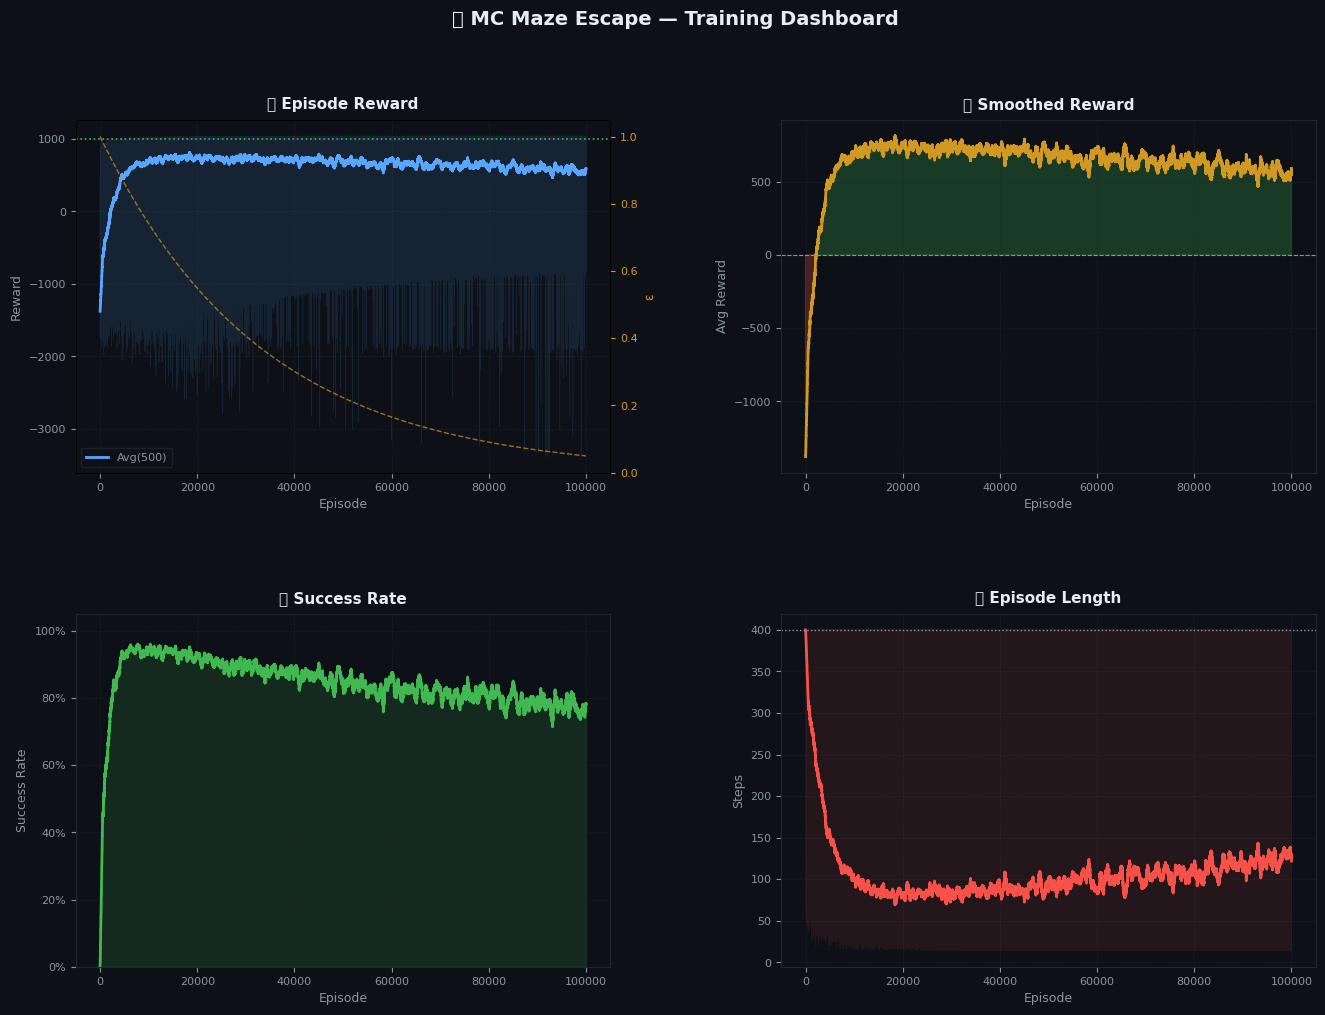

✅ Dashboard saved


In [7]:
# ============================================================
# CELL 7 — Training Dashboard
# ============================================================

def plot_dashboard(agent):
    n  = len(agent.ep_rewards)
    ep = np.arange(1,n+1)
    W  = 500
    sR = agent.running_avg(agent.ep_rewards,W)
    sL = agent.running_avg(agent.ep_lengths,W)
    sS = agent.running_avg(agent.ep_success,W)

    fig=plt.figure(figsize=(16,11)); fig.patch.set_facecolor(PALETTE['bg'])
    fig.suptitle('🧩 MC Maze Escape — Training Dashboard',
                 color=PALETTE['text_main'],fontsize=14,fontweight='bold',y=.98)
    gs =GridSpec(2,2,figure=fig,hspace=.40,wspace=.32)
    axs=[fig.add_subplot(gs[r,c]) for r in range(2) for c in range(2)]

    def sty(ax,t,xl,yl):
        ax.set_facecolor(PALETTE['bg'])
        ax.set_title(t,color=PALETTE['text_main'],fontsize=11,fontweight='bold',pad=8)
        ax.set_xlabel(xl,color=PALETTE['text_dim'],fontsize=9)
        ax.set_ylabel(yl,color=PALETTE['text_dim'],fontsize=9)
        ax.tick_params(colors=PALETTE['text_dim'],labelsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor(PALETTE['grid_line'])
        ax.grid(True,color=PALETTE['grid_line'],ls='--',lw=.5,alpha=.6)

    ax=axs[0]; sty(ax,'📈 Episode Reward','Episode','Reward')
    ax.plot(ep,agent.ep_rewards,color=PALETTE['accent1'],alpha=.12,lw=.4)
    ax.plot(ep,sR,color=PALETTE['accent1'],lw=2,label=f'Avg({W})')
    ax.axhline(CONFIG['REWARD_EXIT'],color=PALETTE['accent2'],ls=':',lw=1.2)
    ax.legend(fontsize=8,facecolor=PALETTE['bg'],labelcolor=PALETTE['text_dim'],
              edgecolor=PALETTE['grid_line'])
    ax2=ax.twinx()
    ax2.plot(ep,agent.ep_eps,color=PALETTE['accent3'],lw=1,ls='--',alpha=.7)
    ax2.set_ylabel('ε',color=PALETTE['accent3'],fontsize=9)
    ax2.tick_params(colors=PALETTE['accent3'],labelsize=8); ax2.set_ylim(0,1.05)

    ax=axs[1]; sty(ax,'📊 Smoothed Reward','Episode','Avg Reward')
    ax.fill_between(ep,sR,0,where=(sR>0), color=PALETTE['accent2'],alpha=.25)
    ax.fill_between(ep,sR,0,where=(sR<=0),color=PALETTE['accent4'],alpha=.25)
    ax.plot(ep,sR,color=PALETTE['accent3'],lw=2)
    ax.axhline(0,color=PALETTE['text_dim'],lw=.8,ls='--')

    ax=axs[2]; sty(ax,'🏆 Success Rate','Episode','Success Rate')
    ax.plot(ep,sS*100,color=PALETTE['accent2'],lw=2)
    ax.fill_between(ep,sS*100,0,color=PALETTE['accent2'],alpha=.15)
    ax.set_ylim(0,105)
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_:f'{x:.0f}%'))

    ax=axs[3]; sty(ax,'⏱ Episode Length','Episode','Steps')
    ax.plot(ep,agent.ep_lengths,color=PALETTE['accent4'],alpha=.1,lw=.4)
    ax.plot(ep,sL,color=PALETTE['accent4'],lw=2)
    ax.axhline(CONFIG['MAX_STEPS'],color=PALETTE['text_dim'],ls=':',lw=1)

    plt.savefig('dashboard.png',dpi=130,bbox_inches='tight',facecolor=PALETTE['bg'])
    plt.show(); print("✅ Dashboard saved")


plot_dashboard(agent)


In [8]:
# ============================================================
# CELL 8 — Save
# ============================================================
agent.save(CONFIG['QTABLE_PATH'])
meta={'q_shape':list(agent.Q.shape),
      'episodes':len(agent.ep_rewards),
      'final_sr':float(np.mean(agent.ep_success[-1000:])),
      'final_avgR':float(np.mean(agent.ep_rewards[-1000:])),
      'best_r':float(np.max(agent.ep_rewards))}
with open('mc_meta.pkl','wb') as f: pickle.dump(meta,f)
print("💾 Saved!")
for k,v in meta.items():
    print(f"   {k:<14}: {v:.4f}" if isinstance(v,float) else f"   {k:<14}: {v}")


💾 Saved!
   q_shape       : [8, 8, 2, 2, 2, 2, 4]
   episodes      : 100000
   final_sr      : 0.7670
   final_avgR    : 552.4664
   best_r        : 1043.1000


In [9]:
# ============================================================
# CELL 9 — Load
# ============================================================
def load_model(config, seed=SEED):
    env_l = MazeEnvironment(config, seed=seed)
    ag    = MonteCarloAgent(env_l, config)
    ag.load(config['QTABLE_PATH'])
    ag.epsilon = 0.0
    if os.path.exists('mc_meta.pkl'):
        with open('mc_meta.pkl','rb') as f: m=pickle.load(f)
        for k,v in m.items():
            print(f"   {k:<14}: {v:.4f}" if isinstance(v,float) else f"   {k:<14}: {v}")
    print("\n✅ Loaded — ε=0 (greedy)")
    return ag

agent_loaded = load_model(CONFIG)
print(f"   Q match  : {np.allclose(agent.Q, agent_loaded.Q)}")


   q_shape       : [8, 8, 2, 2, 2, 2, 4]
   episodes      : 100000
   final_sr      : 0.7670
   final_avgR    : 552.4664
   best_r        : 1043.1000

✅ Loaded — ε=0 (greedy)
   Q match  : True


 🎯  Evaluating on UNSEEN mazes  (ε=0, anti_loop=True)
     n=15  base_seed=88888
   Ep     Seed      Result   Steps     Reward
  --------------------------------------------
    1    88888  ✅ SUCCESS      28    1015.50
    2    89025  ✅ SUCCESS      14    1037.70
    3    89162  ✅ SUCCESS      14    1037.70
    4    89299  ✅ SUCCESS      20    1028.60
    5    89436  ✅ SUCCESS      14    1037.70
    6    89573  ✅ SUCCESS      14    1037.70
    7    89710  ✅ SUCCESS      14    1037.70
    8    89847  ✅ SUCCESS      48     987.10
    9    89984  ✅ SUCCESS      14    1037.70
   10    90121  ✅ SUCCESS      44     995.10
   11    90258  ✅ SUCCESS      38    1001.30
   12    90395  ✅ SUCCESS      14    1037.70
   13    90532  ✅ SUCCESS      20    1031.50
   14    90669  ✅ SUCCESS      14    1037.70
   15    90806  ✅ SUCCESS      14    1037.70

  ── Summary ──────────────────────────────────
  SR=100.0%  AvgR=1026.6  AvgSteps=22


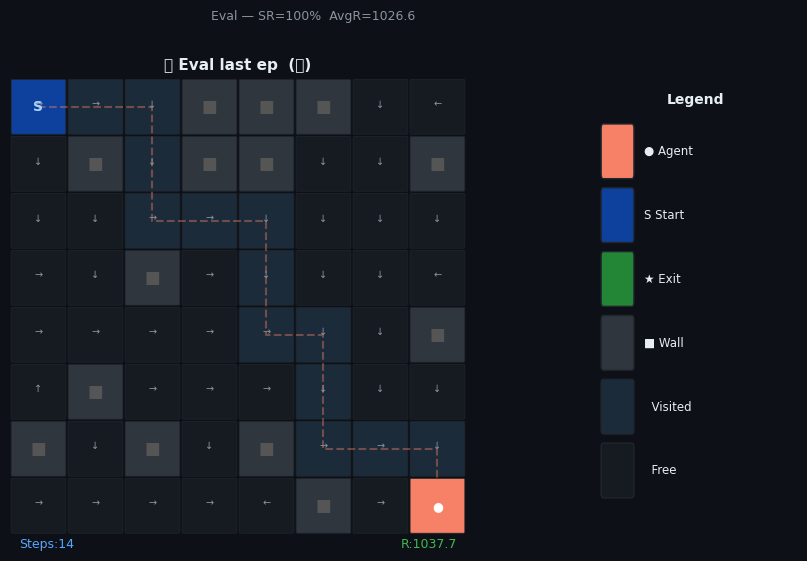

np.float64(100.0)

In [10]:
# ============================================================
# CELL 10 — Evaluation on UNSEEN mazes
# ============================================================

def evaluate(agent, n=15, base_seed=88888):
    print("="*60)
    print(" 🎯  Evaluating on UNSEEN mazes  (ε=0, anti_loop=True)")
    print(f"     n={n}  base_seed={base_seed}")
    print("="*60)
    agent.epsilon=0.0
    rews,lens,succ=[],[],[]
    print(f"  {'Ep':>3}  {'Seed':>7}  {'Result':>10}  {'Steps':>6}  {'Reward':>9}")
    print("  "+"-"*44)
    for i in range(n):
        seed=base_seed+i*137
        agent.env.reseed(seed)
        t,s,r=agent.generate_episode(greedy=True, anti_loop=True)
        rews.append(r); lens.append(len(t)); succ.append(int(s))
        print(f"  {i+1:>3}  {seed:>7}  {'✅ SUCCESS' if s else '❌ FAIL   '}  "
              f"{len(t):>6}  {r:>9.2f}")
    sr=np.mean(succ)*100; ar=np.mean(rews); al=np.mean(lens)
    print(f"\n  ── Summary ──────────────────────────────────")
    print(f"  SR={sr:.1f}%  AvgR={ar:.1f}  AvgSteps={al:.0f}")

    pg=policy_grid(agent,agent.env)
    fig,axes=plt.subplots(1,2,figsize=(10,5.5),gridspec_kw={'width_ratios':[4,1]})
    fig.patch.set_facecolor(PALETTE['bg'])
    draw_maze(agent.env,axes[0],policy_arr=pg,
              title=f'🎯 Eval last ep  ({"✅" if succ[-1] else "❌"})',
              show_policy=True,step_num=lens[-1],ep_reward=rews[-1])
    draw_legend(axes[1])
    plt.suptitle(f'Eval — SR={sr:.0f}%  AvgR={ar:.1f}',
                 color=PALETTE['text_dim'],fontsize=9,y=1.01)
    plt.tight_layout()
    plt.savefig('eval_result.png',dpi=130,bbox_inches='tight',facecolor=PALETTE['bg'])
    plt.show()
    return sr

evaluate(agent_loaded, n=CONFIG['EVAL_EPISODES'])


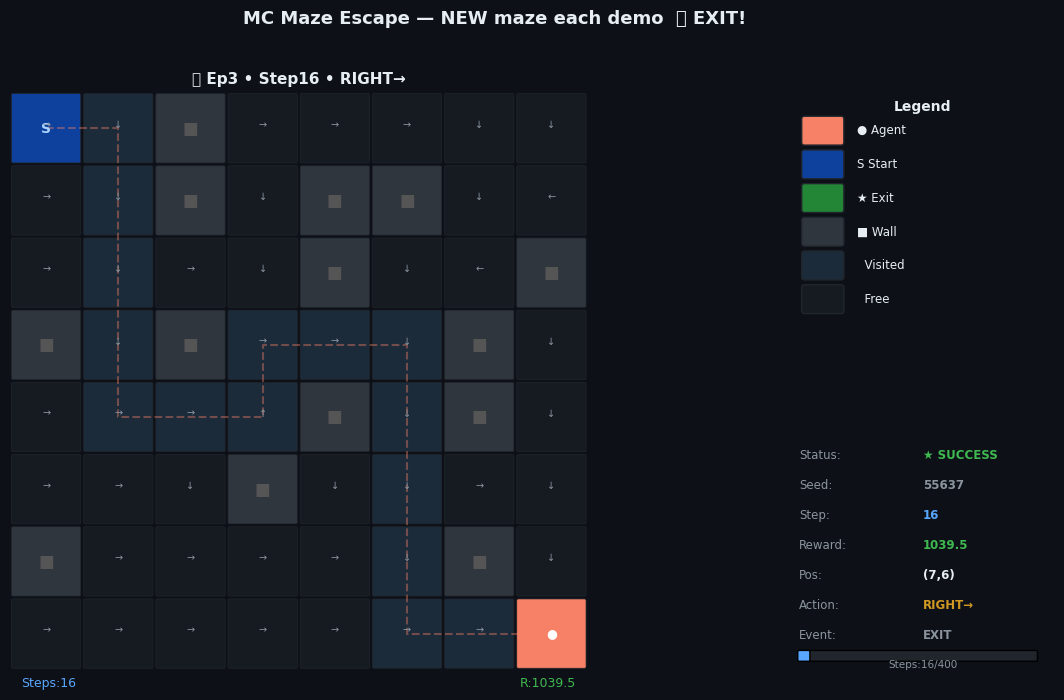

  ✅ SUCCESS  steps=16  reward=1039.50

 🏁 Demo complete!


In [15]:
# ============================================================
# CELL 11 — Live Demo  (new unseen maze every episode)
# ============================================================

def live_demo(agent, base_seed=55555, delay=0.28, n_eps=3):
    agent.epsilon=0.0
    for ep in range(n_eps):
        seed=base_seed+ep*41
        agent.env.reseed(seed)
        state=agent.env.reset()
        done=False; step=0; ep_r=0.0
        pos_cnt=defaultdict(int)

        print(f"\n{'='*60}")
        print(f" 🎮  DEMO ep {ep+1}/{n_eps}  (seed={seed})")
        pg=policy_grid(agent,agent.env)   # compute once for this maze

        while not done:
            r,c=agent.env.agent_pos; pos_cnt[(r,c)]+=1

            # anti-loop: if stuck ≥3 times at same cell → random free direction
            if pos_cnt[(r,c)]>=3:
                free=[a for a,(dr,dc) in enumerate(ACTION_DELTA)
                      if 0<=(r+dr)<agent.env.rows and 0<=(c+dc)<agent.env.cols
                      and agent.env.grid[r+dr,c+dc]!=MazeEnvironment.OBSTACLE]
                action=int(np.random.choice(free)) if free else int(np.random.choice(ACTIONS))
            else:
                action=agent.select_action(state,greedy=True)

            next_state,reward,done,info=agent.env.step(action)
            ep_r+=reward; step+=1; state=next_state

            # ── draw ────────────────────────────────────────────────────
            fig=plt.figure(figsize=(14,7.5)); fig.patch.set_facecolor(PALETTE['bg'])
            gs=GridSpec(2,3,figure=fig,width_ratios=[4,.05,1.6],
                        height_ratios=[1,1],hspace=.40,wspace=.25)
            ax_m=fig.add_subplot(gs[:,0])
            ax_l=fig.add_subplot(gs[0,2])
            ax_s=fig.add_subplot(gs[1,2])

            draw_maze(agent.env,ax_m,policy_arr=pg,
                      title=f'🧩 Ep{ep+1} • Step{step} • {ACTION_NAMES[action]}{ACTION_ARROWS[action]}',
                      show_policy=True,step_num=step,ep_reward=ep_r)
            draw_legend(ax_l)

            # stats
            ax_s.set_facecolor(PALETTE['bg']); ax_s.axis('off')
            if   done and info['event']=='exit': st,sc=('★ SUCCESS',PALETTE['accent2'])
            elif done:                            st,sc=('✕ TIMEOUT',PALETTE['accent4'])
            else:                                st,sc=('⟳ RUNNING',PALETTE['accent1'])
            rows_=[
                ('Status',st,sc),('Seed',str(seed),PALETTE['text_dim']),
                ('Step',str(step),PALETTE['accent1']),
                ('Reward',f'{ep_r:.1f}',PALETTE['reward_pos'] if ep_r>=0 else PALETTE['reward_neg']),
                ('Pos',f'({r},{c})',PALETTE['text_main']),
                ('Action',f'{ACTION_NAMES[action]}{ACTION_ARROWS[action]}',PALETTE['accent3']),
                ('Event',info['event'].upper(),PALETTE['text_dim']),
            ]
            for i,(lbl,val,col) in enumerate(rows_):
                y=.92-i*.125
                ax_s.text(.03,y,lbl+':',transform=ax_s.transAxes,
                          color=PALETTE['text_dim'],fontsize=8.5,va='top')
                ax_s.text(.50,y,val,transform=ax_s.transAxes,
                          color=col,fontsize=8.5,fontweight='bold',va='top')
            prog=step/agent.env.max_steps
            ax_s.add_patch(FancyBboxPatch((.03,.04),.90,.035,
                boxstyle='round,pad=0.005',fc=PALETTE['grid_line'],
                transform=ax_s.transAxes,zorder=1))
            bar_col=PALETTE['accent1'] if prog<.8 else PALETTE['accent4']
            ax_s.add_patch(FancyBboxPatch((.03,.04),.90*min(prog,1),.035,
                boxstyle='round,pad=0.005',fc=bar_col,
                transform=ax_s.transAxes,zorder=2))
            ax_s.text(.5,.01,f'Steps:{step}/{agent.env.max_steps}',
                      transform=ax_s.transAxes,color=PALETTE['text_dim'],
                      fontsize=7.5,ha='center')
            note=('  🎉 EXIT!' if done and info['event']=='exit'
                  else '  ⏰ TIMEOUT' if done else '')
            fig.suptitle(f'MC Maze Escape — NEW maze each demo{note}',
                         color=PALETTE['text_main'],fontsize=13,fontweight='bold',y=.99)
            clear_output(wait=True)
            plt.tight_layout(); plt.show(); plt.close(fig)
            time.sleep(delay)

        res='✅ SUCCESS' if info['event']=='exit' else '❌ TIMEOUT'
        print(f"  {res}  steps={step}  reward={ep_r:.2f}")
        if ep<n_eps-1: time.sleep(2)

    print(f"\n{'='*60}\n 🏁 Demo complete!\n{'='*60}")


# ── policy map on a fresh maze ──────────────────────────────
agent_loaded.env.reseed(13579); agent_loaded.env.reset()
pg=policy_grid(agent_loaded,agent_loaded.env)
fig,axes=plt.subplots(1,2,figsize=(11,6),gridspec_kw={'width_ratios':[4,1]})
fig.patch.set_facecolor(PALETTE['bg'])
draw_maze(agent_loaded.env,axes[0],policy_arr=pg,
          title='🗺 Policy Map — unseen maze (seed 13579)',show_policy=True)
draw_legend(axes[1])
plt.tight_layout()
plt.savefig('policy_map.png',dpi=130,bbox_inches='tight',facecolor=PALETTE['bg'])
plt.show()

print("\n🎮 Starting live demo...")
time.sleep(1)
live_demo(agent_loaded, base_seed=55555, delay=0.28, n_eps=3)
